# 📊 PROYEK MACHINE LEARNING  
## Clustering dan Klasifikasi untuk Analisis Transaksi Keuangan


# INFORMASI DATASET

Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Tujuan Proyek

Tugas pada proyek ini adalah:

1. Membangun **model Clustering** untuk mengelompokkan pola transaksi
2. Menggunakan hasil clustering sebagai **label Target**
3. Membangun **model Klasifikasi** menggunakan Decision Tree
4. Mengevaluasi performa model klasifikasi

Model clustering akan digunakan untuk menemukan pola tersembunyi dalam data transaksi, kemudian hasil cluster tersebut akan digunakan sebagai label untuk model klasifikasi.

---

## Fitur Utama Dataset

- **TransactionID**: Pengidentifikasi unik alfanumerik untuk setiap transaksi  
- **AccountID**: ID unik untuk setiap akun, dapat memiliki banyak transaksi  
- **TransactionAmount**: Nilai transaksi dalam mata uang  
- **TransactionDate**: Tanggal dan waktu transaksi terjadi  
- **TransactionType**: Tipe transaksi berupa Credit atau Debit  
- **Location**: Lokasi geografis transaksi  
- **DeviceID**: ID perangkat yang digunakan dalam transaksi  
- **IPAddress**: Alamat IPv4 yang digunakan saat transaksi  
- **MerchantID**: ID unik merchant  
- **AccountBalance**: Saldo akun setelah transaksi berlangsung  
- **PreviousTransactionDate**: Tanggal transaksi terakhir pada akun  
- **Channel**: Kanal transaksi seperti Online, ATM, atau Branch  
- **CustomerAge**: Usia pemilik akun  
- **CustomerOccupation**: Profesi pengguna  
- **TransactionDuration**: Lama waktu transaksi (detik)  
- **LoginAttempts**: Jumlah upaya login sebelum transaksi  

---

## Alur Machine Learning

Tahapan yang dilakukan pada proyek ini:

1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Cleaning
4. Data Preprocessing
5. Clustering menggunakan K-Means
6. Interpretasi Cluster
7. Menyimpan hasil clustering
8. Klasifikasi menggunakan Decision Tree
9. Evaluasi Model
10. Penyimpanan Model

# **1. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning. Semua library yang dibutuhkan harus **import** di **cell** ini, jika ada library yang dijalankan di cell lain maka **submission langsung ditolak**

In [1]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
import joblib
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# **2. Load Dataset**


Penjelasan:
Pada tahap ini dataset dimuat menggunakan pandas. Fungsi read_csv digunakan untuk membaca file dataset dalam format CSV. Setelah dataset dimuat, ditampilkan lima data pertama untuk melihat struktur awal data.

In [16]:
# Load data

### MULAI CODE ###

url = "https://docs.google.com/spreadsheets/d/1u-R-oQv2hwB3M1BqAvsnZCJ7d3GYgaK5UWatx3w4qrA/export?format=csv"
df = pd.read_csv(url)

In [17]:
# Menampilkan informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            500 non-null    int64  
 1   type            500 non-null    object 
 2   amount          500 non-null    float64
 3   nameOrig        500 non-null    object 
 4   oldbalanceOrg   500 non-null    float64
 5   newbalanceOrig  500 non-null    float64
 6   nameDest        500 non-null    object 
 7   oldbalanceDest  500 non-null    float64
 8   newbalanceDest  500 non-null    float64
 9   isFraud         500 non-null    int64  
 10  isFlaggedFraud  500 non-null    int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 43.1+ KB


In [20]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,500.000000,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,500.000000,500.0
mean,3.628000,1.147385e+05,1.263309e+06,1.308013e+06,1.141656e+06,1.344026e+06,0.008000,0.0
std,2.335063,2.329384e+05,2.481723e+06,2.534434e+06,2.916324e+06,3.334669e+06,0.089173,0.0
min,1.000000,6.930000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,1.000000,4.352858e+03,8.782500e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,4.000000,1.669893e+04,3.095150e+04,2.544399e+04,0.000000e+00,0.000000e+00,0.000000,0.0
75%,6.000000,1.542933e+05,1.289448e+06,1.346167e+06,4.910997e+05,5.773191e+05,0.000000,0.0
max,7.000000,2.930418e+06,1.206282e+07,1.214958e+07,1.766482e+07,1.916920e+07,1.000000,0.0


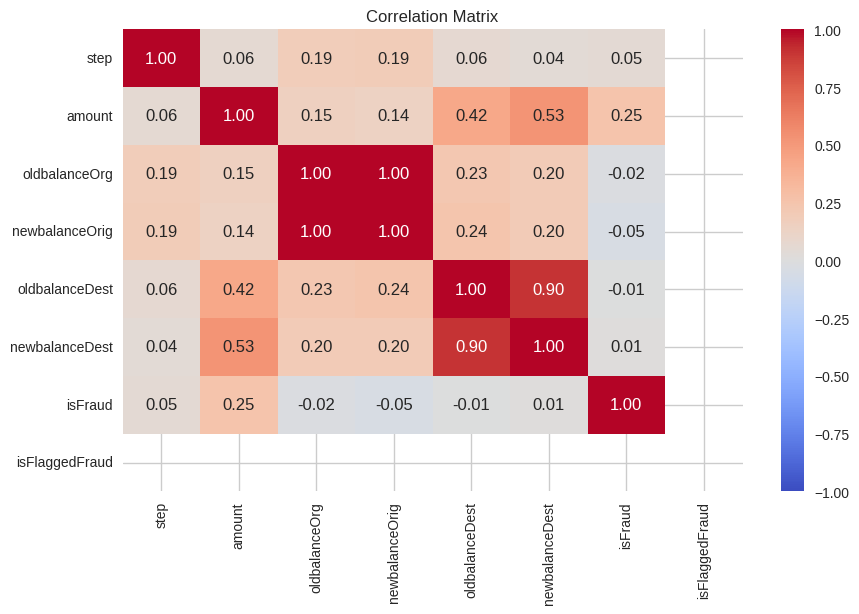

In [21]:
# Menampilkan korelasi antar fitur (Opsional Skilled 1)

# Memilih kolom numerik
numerical_cols = df.select_dtypes(include=['number']).columns


# Hitung matriks korelasi
correlation = df[numerical_cols].corr()

# Buat visualisasi heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation,
               annot=True,
               cmap='coolwarm',
               fmt=".2f",
               vmin=-1,
               vmax=1)
plt.title('Correlation Matrix')
plt.show()


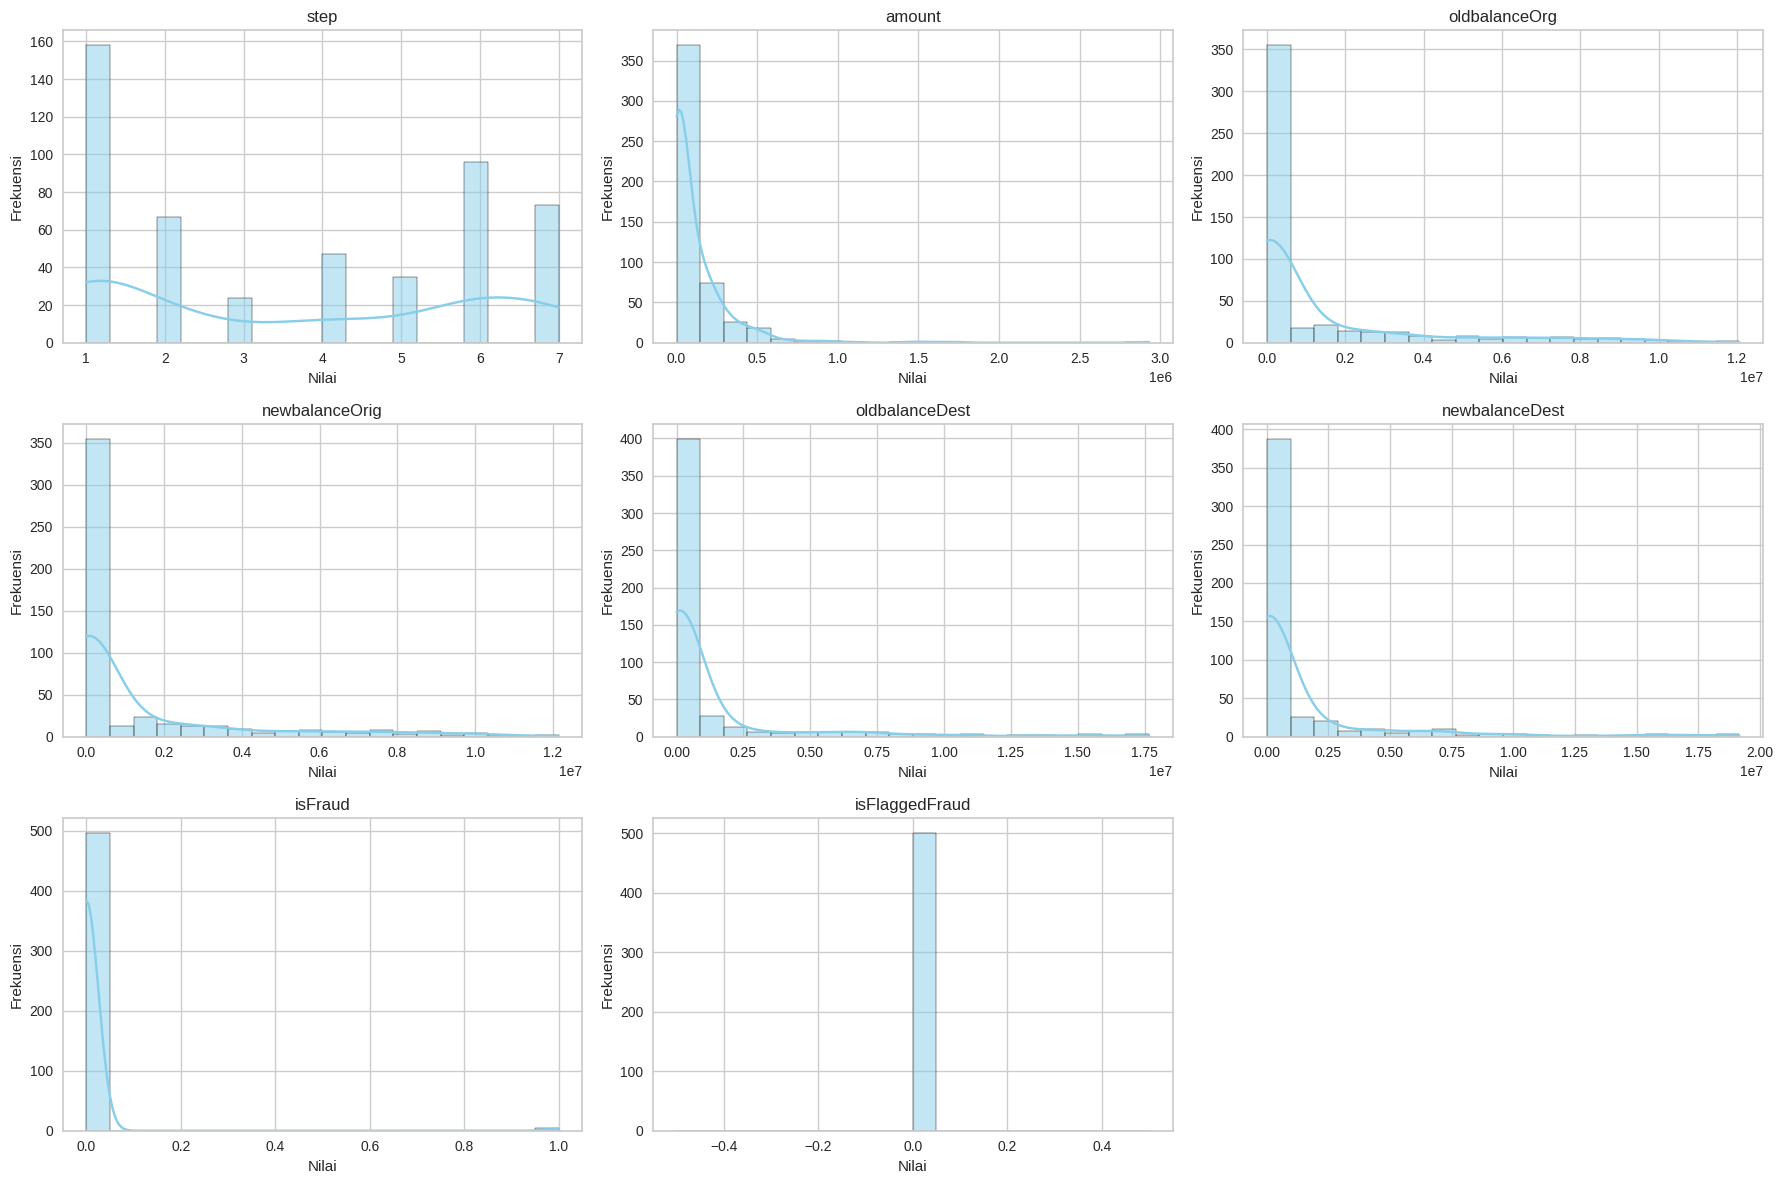

In [22]:
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)

import math

n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten()

for i, column in enumerate(numerical_cols):

    # Tampilkan histogram
    sns.histplot(df[column], bins=20, kde=True, color='skyblue', ax=axes[i])

    # Atur judul dan label
    axes[i].set_title(column)
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")

# Hapus subplot kosong
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

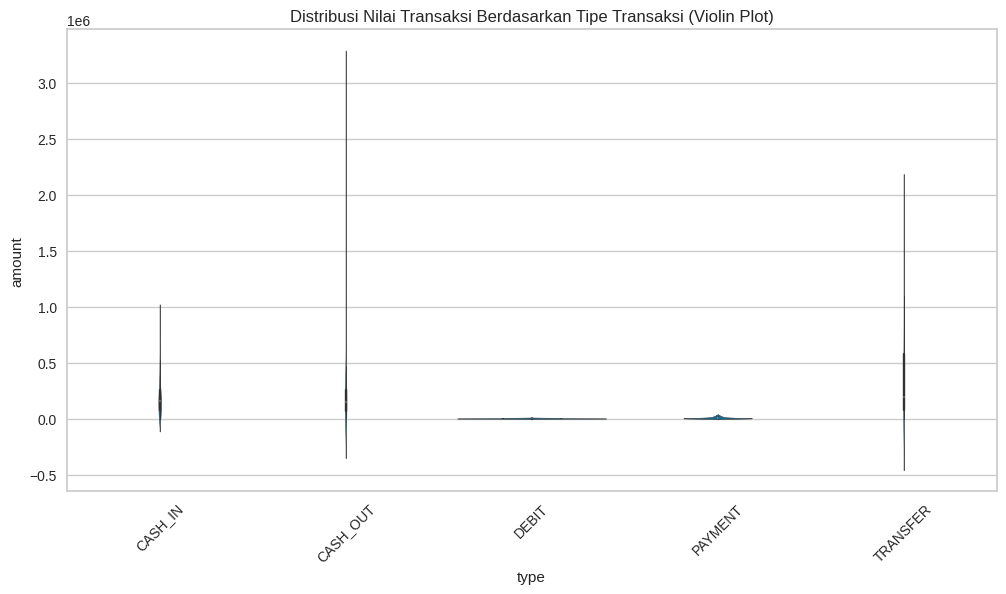

In [25]:
# **Visualisasi Violin Plot Distribusi Nilai Transaksi**
# Visualisasi ini digunakan untuk melihat distribusi data yang lebih detail
# dibandingkan boxplot, termasuk kepadatan distribusi tiap tipe transaksi.

### MULAI CODE ###

plt.figure(figsize=(12, 6))

# Membuat violin plot nilai transaksi berdasarkan tipe transaksi
sns.violinplot(x='type', y='amount', data=df)

# Menambahkan judul
plt.title("Distribusi Nilai Transaksi Berdasarkan Tipe Transaksi (Violin Plot)")

# Memutar label
plt.xticks(rotation=45)

# Menampilkan plot
plt.show()

### SELESAI CODE ###

# **3. Pembersihan dan Pra Pemrosesan Data**

Pada tahap ini, Anda akan melakukan **Pembersihan Dataset** untuk menjadikan dataset mudah diintepretasi dan bisa dilatih. Hal-hal yang wajib kamu lakukan yaitu:



In [26]:
# Mengecek dataset menggunakan isnull().sum()
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [27]:
# Mengecek dataset menggunakan duplicated().sum()
df.duplicated().sum()

np.int64(0)

In [28]:
# Menangani data yang hilang.

# Panggil fungsi untuk menghapus baris yang hilang dan pastikan agar perubahan disimpan kembali ke 'df'
df.dropna(inplace=True)

# Cek kembali dataset menggunakan isnull().sum()
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [29]:
# Menghapus data duplikat.

# Panggil fungsi untuk menghapus baris duplikat dan pastikan agar perubahan disimpan kembali ke 'df'
df.drop_duplicates(inplace=True)

# Cek kembali dataset menggunakan duplicated().sum()
df.duplicated().sum()

np.int64(0)

In [30]:
# Melakukan drop pada kolom yang memiliki keterangan Date, id, dan IP Address

# Buat list comprehension untuk memfilter nama kolom.
#    - Iterasi melalui semua nama kolom (col).
#    - Cek apakah 'id', 'ip', atau 'date' ada di nama kolom.
#    - Gunakan .lower() untuk membuat perbandingan case-insensitive (mengabaikan besar/kecil).

cols_to_drop = [col for col in df.columns if
                'id' in col.lower() or
                'ip' in col.lower() or
                'date' in col.lower()]

# Gunakan fungsi .drop() untuk menghapus kolom-kolom yang ada di 'cols_to_drop'.
df = df.drop(columns=cols_to_drop)

# Tampilkan 5 baris pertama untuk memverifikasi
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,CASH_IN,25090.03,C864221358,6572510.82,6597600.85,C1282788025,80148.60,0.00,0,0
1,1,CASH_IN,135324.19,C1751403001,1372752.22,1508076.41,C453211571,1356747.89,3461666.05,0,0
2,1,CASH_IN,21670.38,C1713605602,3134978.74,3156649.13,C215145189,54530.44,1891.79,0,0
3,1,CASH_IN,223123.71,C951988316,5033779.71,5256903.42,C1359044626,394281.87,16518.36,0,0
4,1,CASH_IN,131011.30,C1618099562,2614949.53,2745960.83,C1688019098,228275.07,97263.78,0,0


In [31]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.
# Pastikan kamu menggunakan function head setelah melalukan encoding.

# Pilih semua kolom yang bertipe 'object' (kategorikal)
categorical_cols = list(df.select_dtypes(include=['object']).columns)

encoders = {}

# Loop melalui setiap kolom kategorikal
for column in categorical_cols:
    # Buat (instantiate) objek LabelEncoder
    label_encoder = LabelEncoder()

    # Terapkan (fit) encoder ke data dan sekaligus ubah (transform) data tersebut
    df[column] = label_encoder.fit_transform(df[column])

    # Simpan encoder
    encoders[column] = label_encoder

# Tampilkan 5 baris pertama untuk memverifikasi hasil encoding
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,0,25090.03,460,6572510.82,6597600.85,22,80148.60,0.00,0,0
1,1,0,135324.19,206,1372752.22,1508076.41,131,1356747.89,3461666.05,0,0
2,1,0,21670.38,190,3134978.74,3156649.13,111,54530.44,1891.79,0,0
3,1,0,223123.71,479,5033779.71,5256903.42,31,394281.87,16518.36,0,0
4,1,0,131011.30,168,2614949.53,2745960.83,67,228275.07,97263.78,0,0


In [32]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.
# Perbaiki kode di bawah ini tanpa menambahkan atau mengurangi cell code ini.
df.columns.tolist()

['step',
 'type',
 'amount',
 'nameOrig',
 'oldbalanceOrg',
 'newbalanceOrig',
 'nameDest',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'isFlaggedFraud']

In [33]:
# Melakukan Handling Outlier Data menggunakan metode drop.

for col in numerical_cols:


    # Hitung Kuartil 1 (Q1) dan Kuartil 3 (Q3)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Hitung Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Tentukan batas bawah (lower bound) dan batas atas (upper bound)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter DataFrame: Simpan hanya baris di mana nilai 'df[col]' berada DI ANTARA (inklusif) batas bawah dan batas atas.
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Tampilkan statistik deskriptif setelah outlier dihapus
df.describe()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000,227.0,227.0,227.0
mean,3.180617,2.969163,8402.401145,244.215859,31648.309251,27811.977269,301.810573,172.595683,0.0,0.0,0.0
std,2.094657,0.303258,9619.251208,149.511334,49138.556660,48161.534010,77.360976,1577.333186,0.0,0.0,0.0
min,1.000000,0.000000,6.930000,0.000000,0.000000,0.000000,39.000000,0.000000,0.0,0.0,0.0
25%,1.000000,3.000000,2638.485000,111.000000,306.500000,0.000000,241.500000,0.000000,0.0,0.0,0.0
50%,2.000000,3.000000,5393.370000,233.000000,11352.000000,5748.890000,302.000000,0.000000,0.0,0.0,0.0
75%,6.000000,3.000000,10704.760000,378.500000,40657.500000,35841.190000,366.500000,0.000000,0.0,0.0,0.0
max,6.000000,4.000000,93413.630000,497.000000,234028.000000,220759.930000,429.000000,20767.000000,0.0,0.0,0.0


In [34]:
# Melakukan feature scaling menggunakan StandardScaler() untuk fitur numerik.
# Pastikan kamu menggunakan function head setelah melalukan scaling.


# Buat (instantiate) StandardScaler
scaler = StandardScaler()

# Terapkan (fit) scaler ke data dan sekaligus ubah (transform) data tersebut
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Tampilkan 5 baris pertama untuk memverifikasi hasil scaling
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
11,-1.043338,0,8.857145,325,-0.460478,1.553889,64,1.976932,0.0,0.0,0.0
51,-1.043338,2,-0.544142,42,1.897923,1.950089,57,13.085325,0.0,0.0,0.0
53,-1.043338,2,-0.551211,380,0.673412,0.702149,113,6.288778,0.0,0.0,0.0
57,-1.043338,3,0.032722,315,-0.477508,-0.578749,342,-0.109664,0.0,0.0,0.0
58,-1.043338,3,-0.438953,491,1.896182,1.927304,393,-0.109664,0.0,0.0,0.0


In [35]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,
# lakukan pada satu sampai dua fitur numerik.
# Silahkan lakukan encode hasil binning tersebut menggunakan LabelEncoder.
# Pastikan kamu mengerjakan tahapan ini pada satu cell.

# Tentukan kolom numerik yang ingin Anda kelompokkan
col_to_bin = 'amount'  # (Isi dengan kolom numerik lain jika berbeda)

# Tentukan nama untuk kolom kategori baru
new_col_name = 'amount_category'

# Tentukan label untuk 3 grup (Mulai dari rendah --> sedang --> tinggi)
bin_labels = ['rendah', 'sedang', 'tinggi']

# Gunakan 'pd.qcut' untuk membagi data menjadi 3 kelompok
df[new_col_name] = pd.qcut(df[col_to_bin], q=3, labels=bin_labels, duplicates='drop')

# Lakukan Label Encoding pada kolom baru ini agar menjadi numerik
label_encoder = LabelEncoder()
df[new_col_name] = label_encoder.fit_transform(df[new_col_name])

# Simpan encoder dan tambahkan nama kolom baru ke 'categorical_cols'
encoders[new_col_name] = label_encoder
categorical_cols.extend([new_col_name])

# Tampilkan 5 baris pertama untuk memverifikasi
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,amount_category
11,-1.043338,0,8.857145,325,-0.460478,1.553889,64,1.976932,0.0,0.0,0.0,2
51,-1.043338,2,-0.544142,42,1.897923,1.950089,57,13.085325,0.0,0.0,0.0,0
53,-1.043338,2,-0.551211,380,0.673412,0.702149,113,6.288778,0.0,0.0,0.0,0
57,-1.043338,3,0.032722,315,-0.477508,-0.578749,342,-0.109664,0.0,0.0,0.0,2
58,-1.043338,3,-0.438953,491,1.896182,1.927304,393,-0.109664,0.0,0.0,0.0,1


# **4. Membangun Model Clustering**
Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan.
1. Pastikan Anda menggunakan dataframe yang sudah melalui processing sesuai dengan levelnya (Basic, Skilled, Advanced)
2. Melakukan visualisasi Elbow Method untuk menentukan jumlah cluster terbaik menggunakan `KElbowVisualizer()`.
3. Menggunakan algoritma K-Means Clustering dengan `sklearn.cluster.KMeans()`.
4. Jalankan cell code `joblib.dump(model_kmeans, "model_clustering.h5")` untuk menyimpan model yang sudah dibuat.

In [36]:
# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
# Lengkapi kode ini dengan mengubah nama DataFrame yang akan dilatih.
# Kode harus digunakan dan dilarang menambahkan syntax lainnya pada cell ini.

# Buat salinan (copy) dari 'df' ke variabel 'df_used'
df_used = df.copy()

# Tampilkan ringkasan statistik dari DataFrame 'df'
df_used.describe()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,amount_category
count,2.270000e+02,227.000000,2.270000e+02,227.000000,2.270000e+02,2.270000e+02,227.000000,2.270000e+02,227.0,227.0,227.0,227.000000
mean,-1.252058e-16,2.969163,1.721579e-16,244.215859,-1.075987e-16,-1.115114e-16,301.810573,-3.912680e-17,0.0,0.0,0.0,1.000000
std,1.002210e+00,0.303258,1.002210e+00,149.511334,1.002210e+00,1.002210e+00,77.360976,1.002210e+00,0.0,0.0,0.0,0.820101
min,-1.043338e+00,0.000000,-8.747068e-01,0.000000,-6.454860e-01,-5.787490e-01,39.000000,-1.096643e-01,0.0,0.0,0.0,0.000000
25%,-1.043338e+00,3.000000,-6.005305e-01,111.000000,-6.392348e-01,-5.787490e-01,241.500000,-1.096643e-01,0.0,0.0,0.0,0.000000
50%,-5.648781e-01,3.000000,-3.135048e-01,233.000000,-4.139552e-01,-4.591184e-01,302.000000,-1.096643e-01,0.0,0.0,0.0,1.000000
75%,1.348963e+00,3.000000,2.398780e-01,378.500000,1.837478e-01,1.670827e-01,366.500000,-1.096643e-01,0.0,0.0,0.0,2.000000
max,1.348963e+00,4.000000,8.857145e+00,497.000000,4.127654e+00,4.015120e+00,429.000000,1.308532e+01,0.0,0.0,0.0,2.000000


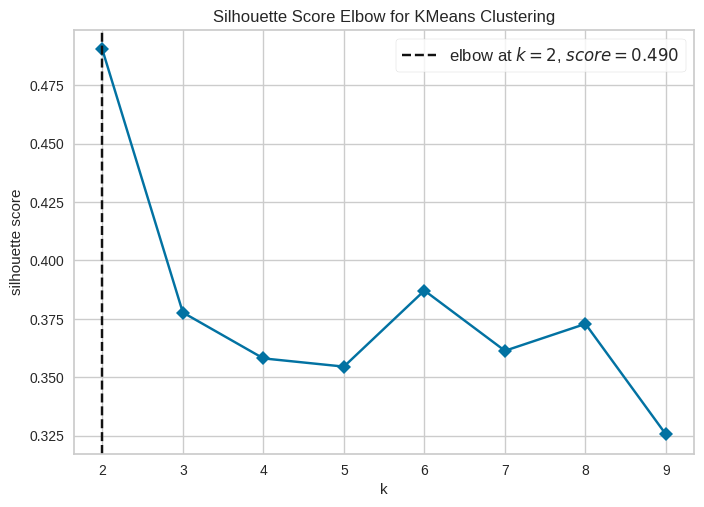

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [37]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()

# Buat (instantiate) model clustering
model = KMeans()

# Buat (instantiate) KElbowVisualizer
#  - Masukkan 'model' yang akan digunakan
#  - Tentukan jumlah cluster yang akan diuji (range 2 sampai 10)
#  - Tentukan 'metric' evaluasi
visualizer = KElbowVisualizer(model,
                       k=(2,10),
                       metric='silhouette',
                       timings=False)

# Jalankan (fit) visualizer pada data
visualizer.fit(df)

# Tampilkan plot
visualizer.show()

In [38]:
# Menggunakan algoritma K-Means Clustering

# Buat (instantiate) objek model KMeans
#  - Tentukan jumlah cluster (n_clusters)
model = KMeans(n_clusters=3, random_state=42)

# Latih (fit) model dengan data Anda (df)
model.fit(df)

KMeans(n_clusters=3, random_state=42)

In [39]:
# Menyimpan model menggunakan joblib

# Simpan model clustering yang sudah dilatih
joblib.dump(model, "model_clustering.h5")

['model_clustering.h5']

In [40]:
# Menghitung dan menampilkan nilai Silhouette Score.

# Dapatkan hasil (label) cluster dari model 'kmeans' yang telah di-fit
labels = model.labels_

# Panggil fungsi untuk menghitung silhouette score
score = silhouette_score(df, labels)

# Cetak skornya
print("Silhouette Score:", score)

Silhouette Score: 0.37772849045132895


/tmp/ipykernel_8422/1921755394.py:17: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


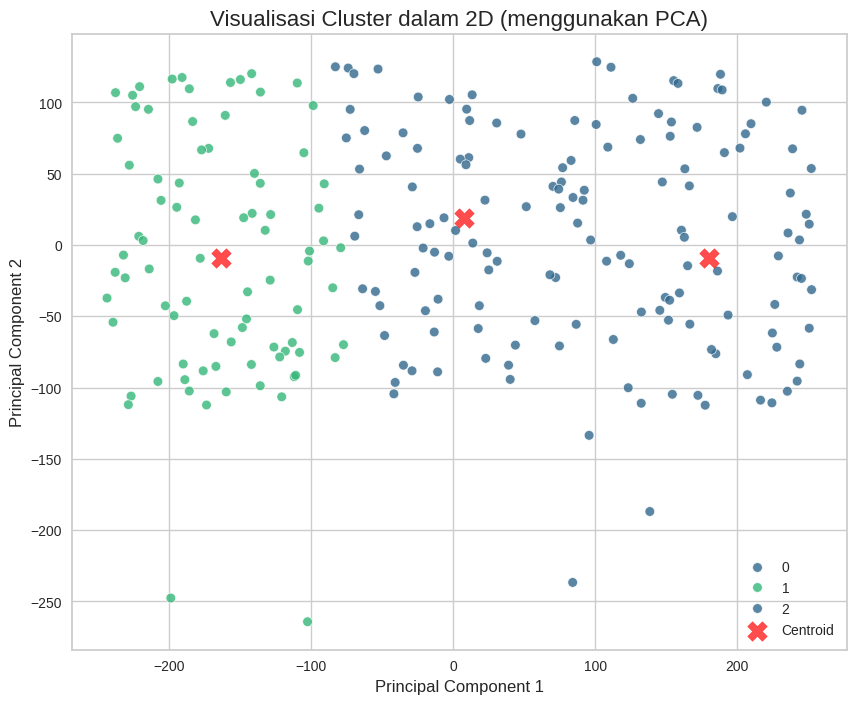

In [41]:
# Membuat visualisasi hasil clustering

# Buat (instantiate) objek PCA untuk 2 komponen (n_components=2)
pca = PCA(n_components=2)

# Terapkan (fit) PCA ke data 'df' dan transformasikan data tersebut
df_pca = pca.fit_transform(df)

# Buat DataFrame baru 'df_pca' dari hasil transformasi
df_pca = pd.DataFrame(data=df_pca, columns=['Principal Component 1', 'Principal Component 2'])

# Tambahkan kolom 'Cluster' ke 'df_pca' menggunakan 'labels'(variabel dari hasil 'kmeans.labels_' sebelumnya)
df_pca['Cluster'] = labels

# Buat scatter plot menggunakan Seaborn
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster',  # Warnai titik berdasarkan kolom 'Cluster'
    palette=sns.color_palette("viridis", n_colors=2),
    data=df_pca,
    legend="full",
    alpha=0.8
)

plt.title('Visualisasi Cluster dalam 2D (menggunakan PCA)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
centers = pca.transform(model.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.7, marker='X', label='Centroid')
plt.legend()
plt.show()

In [42]:
# Membangun model menggunakan PCA.

# Buat (instantiate) objek PCA dengan 2 komponen
pca = PCA(n_components=2)

# Terapkan (fit) PCA ke data 'df_used' dan transformasikan data tersebut
df_pca_array = pca.fit_transform(df_used)

# Buat DataFrame baru 'data_final' dari hasil array PCA
data_final = pd.DataFrame(data=df_pca_array, columns=['PCA1', 'PCA2'])

# Buat (instantiate) model KMeans BARU
kmeans_pca = KMeans(n_clusters=3, random_state=42)

# Latih (fit) model KMeans BARU ini HANYA pada 'data_final'
kmeans_pca.fit(data_final)

KMeans(n_clusters=3, random_state=42)

In [43]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini joblib.dump(model,"PCA_model_clustering.h5")

# Pastikan yang disimpan model yang sudah melalui .fit berdasarkan dataset yang sudah dilakukan PCA
joblib.dump(kmeans_pca, "PCA_model_clustering.h5")

['PCA_model_clustering.h5']

# **5. Interpretasi Cluster**
## **a. Interpretasi Hasil Clustering**
1. **Contoh Interpretasi:**
- **Cluster 1: (Nasabah Bertransaksi dan Pendapatan Besar)**:
  - **Rata-rata (mean) Transaction Amount:** -0.01
  - **Rata-rata (mean) Customer Age:** 0.32
  - **Analisis:** Cluster ini mencakup pelanggan usia lanjut usia dengan jumlah transaksi yang dilakukan cukup rendah. Pelanggan dalam cluster ini cenderung memiliki daya beli yang rendah dan cenderung bermain aman. Sehingga rekomendasi pada kelompok nasabah ini adalah dengan menawarkan produk-produk investasi atau perbankan dengan resiko rendah.


In [44]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
# Silakan menambahkan fungsi agregasi lainnya untuk experience lebih baik.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max.

# Tambahkan kolom 'Cluster' baru berupa 'labels' (variabel dari 'kmeans.labels_' sebelumnya)
df_used['Cluster'] = labels

# Kelompokkan (groupby) 'df_used' berdasarkan 'Cluster' dan hitung agregasi untuk 'numerical_cols'.
agg_summary = df_used.groupby('Cluster')[numerical_cols].agg(['mean', 'min', 'max']).round(2).T

# Tampilkan hasil ringkasan
display(agg_summary)

Cluster                 0      1     2
step           mean -0.14   0.09  0.04
               min  -1.04  -1.04 -1.04
               max   1.35   1.35  1.35
amount         mean  0.23  -0.20  0.01
               min  -0.87  -0.87 -0.83
               max   8.86   2.96  2.46
oldbalanceOrg  mean -0.10   0.04  0.06
               min  -0.65  -0.65 -0.65
               max   3.37   3.75  4.13
newbalanceOrig mean -0.09   0.04  0.04
               min  -0.58  -0.58 -0.58
               max   3.30   3.86  4.02
oldbalanceDest mean  0.06   0.05 -0.11
               min  -0.11  -0.11 -0.11
               max   6.29  13.09 -0.11
newbalanceDest mean  0.00   0.00  0.00
               min   0.00   0.00  0.00
               max   0.00   0.00  0.00
isFraud        mean  0.00   0.00  0.00
               min   0.00   0.00  0.00
               max   0.00   0.00  0.00
isFlaggedFraud mean  0.00   0.00  0.00
               min   0.00   0.00  0.00
               max   0.00   0.00  0.00

# **6. Mengeksport Data**

1. Simpan nama kolom hasil clustering dengan nama `Target`.
2. Simpan hasilnya ke dalam file CSV menggunakan function `to_csv()`.

In [45]:
# Pastikan nama kolom clustering sudah diubah menjadi Target

df_used.rename(columns={"Cluster": "Target"}, inplace=True)

# Tampilkan 5 baris pertama untuk memverifikasi
df_used.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,amount_category,Target
11,-1.043338,0,8.857145,325,-0.460478,1.553889,64,1.976932,0.0,0.0,0.0,2,0
51,-1.043338,2,-0.544142,42,1.897923,1.950089,57,13.085325,0.0,0.0,0.0,0,1
53,-1.043338,2,-0.551211,380,0.673412,0.702149,113,6.288778,0.0,0.0,0.0,0,0
57,-1.043338,3,0.032722,315,-0.477508,-0.578749,342,-0.109664,0.0,0.0,0.0,2,2
58,-1.043338,3,-0.438953,491,1.896182,1.927304,393,-0.109664,0.0,0.0,0.0,1,0


In [46]:
# Simpan Data

df_used.to_csv('data_clustering.csv', index=False)

In [47]:
# inverse dataset ke rentang normal untuk numerikal

df_inverse = df_used.copy()

# Gunakan 'scaler' untuk mengembalikan 'numerical_cols' ke nilai aslinya.
df_inverse[numerical_cols] = scaler.inverse_transform(df_inverse[numerical_cols])

# Tampilkan 5 baris pertama untuk memverifikasi hasilnya
df_inverse.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,amount_category,Target
11,1.0,0,93413.63,325,9071.00,102484.63,64,3284.00,0.0,0.0,0.0,2,0
51,1.0,2,3179.70,42,124703.85,121524.14,57,20767.00,0.0,0.0,0.0,0,1
53,1.0,2,3111.86,380,64665.82,61553.96,113,10070.22,0.0,0.0,0.0,0,0
57,1.0,3,8716.47,315,8236.00,0.00,342,0.00,0.0,0.0,0.0,2,2
58,1.0,3,4189.31,491,124618.50,120429.20,393,0.00,0.0,0.0,0.0,1,0


In [48]:
# inverse dataset yang sudah diencode ke kategori aslinya.

for column in categorical_cols:
    # Ambil encoder yang tepat untuk 'column' dari dictionary 'encoders'
    encoder = encoders[column]

    # Gunakan encoder untuk mengembalikan (inverse) kolom tersebut
    df_inverse[column] = encoder.inverse_transform(df_inverse[column].astype(int))

# Tampilkan 5 baris pertama untuk memverifikasi hasilnya
df_inverse.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,amount_category,Target
11,1.0,CASH_IN,93413.63,C263588219,9071.00,102484.63,C1620301064,3284.00,0.0,0.0,0.0,tinggi,0
51,1.0,DEBIT,3179.70,C1182311147,124703.85,121524.14,C1540270363,20767.00,0.0,0.0,0.0,rendah,1
53,1.0,DEBIT,3111.86,C548795052,64665.82,61553.96,C240650537,10070.22,0.0,0.0,0.0,rendah,0
57,1.0,PAYMENT,8716.47,C215759534,8236.00,0.00,M2129844134,0.00,0.0,0.0,0.0,tinggi,2
58,1.0,PAYMENT,4189.31,C978035840,124618.50,120429.20,M666312528,0.00,0.0,0.0,0.0,sedang,0


In [49]:
# Lakukan analisis deskriptif minimal mean, min dan max untuk fitur numerik dan mode untuk kategorikal seperti pada basic tetapi menggunakan data yang sudah diinverse.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max kembali setelah melakukan inverse.

# Kelompokkan (groupby) 'df_inverse' berdasarkan 'Target' dan hitung agregasi untuk 'numerical_cols'.
agg_summary_num = df_inverse.groupby('Target')[numerical_cols].agg(['mean', 'min', 'max']).round(2).T

# Kelompokkan (groupby) 'df_inverse' berdasarkan 'Target' dan hitung agregasi untuk 'categorical_cols'.
#   - Hitung agregasi (agg) 'mode' (nilai yang paling sering muncul).
#   - (Kita gunakan 'lambda x: x.mode()[0]' untuk mengambil nilai mode pertama)
agg_summary_cat = df_inverse.groupby('Target')[categorical_cols].agg(lambda x: x.mode()[0]).T


# Tampilkan kedua hasil ringkasan
display(agg_summary_num)
display(agg_summary_cat)

Target                       0          1          2
step           mean       2.89       3.37       3.26
               min        1.00       1.00       1.00
               max        6.00       6.00       6.00
amount         mean   10570.23    6472.91    8460.54
               min        6.93      46.88     438.55
               max    93413.63   36774.88   31984.61
oldbalanceOrg  mean   26510.20   33614.10   34399.81
               min        0.00       0.00       0.00
               max   196907.98  215507.00  234028.00
newbalanceOrig mean   23496.93   29833.77   29711.72
               min        0.00       0.00       0.00
               max   186344.56  213274.17  220759.93
oldbalanceDest mean     259.33     253.26       0.00
               min        0.00       0.00       0.00
               max    10070.22   20767.00       0.00
newbalanceDest mean       0.00       0.00       0.00
               min        0.00       0.00       0.00
               max        0.00       0.00       0.00
isFraud        mean       0.00       0.00       0.00
               min        0.00       0.00       0.00
               max        0.00       0.00       0.00
isFlaggedFraud mean       0.00       0.00       0.00
               min        0.00       0.00       0.00
               max        0.00       0.00       0.00

Target,0,1,2
type,PAYMENT,PAYMENT,PAYMENT
nameOrig,C263588219,C1003307628,C1607566361
nameDest,C1620301064,C1428469551,M1095918240
amount_category,tinggi,rendah,tinggi


In [50]:
# Periksa kembali data yang telah di-inverse.

df_inverse.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,amount_category,Target
11,1.0,CASH_IN,93413.63,C263588219,9071.00,102484.63,C1620301064,3284.00,0.0,0.0,0.0,tinggi,0
51,1.0,DEBIT,3179.70,C1182311147,124703.85,121524.14,C1540270363,20767.00,0.0,0.0,0.0,rendah,1
53,1.0,DEBIT,3111.86,C548795052,64665.82,61553.96,C240650537,10070.22,0.0,0.0,0.0,rendah,0
57,1.0,PAYMENT,8716.47,C215759534,8236.00,0.00,M2129844134,0.00,0.0,0.0,0.0,tinggi,2
58,1.0,PAYMENT,4189.31,C978035840,124618.50,120429.20,M666312528,0.00,0.0,0.0,0.0,sedang,0


In [51]:
# Simpan Data Inverse

df_inverse.to_csv('data_clustering_inverse.csv', index=False)